<a href="https://colab.research.google.com/github/sebaton/ProgrammingAssignment2/blob/master/Optimizador_de_secuencias_definitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Optimizador de secuencias basado en CodonTransformer**

[Link a GitHub](https://github.com/Adibvafa/CodonTransformer/tree/main)
- Antes de usar, realizar una copia del archivo
- Seleccionar `Archivo` -> `Guardar una copia en drive` para guardar este cuadernoto save this notebook.
- Cada celda se corre tocando el simbolo ▶️.


In [ ]:
#@title Instalar Paquetes
%%capture
!pip uninstall numpy -y
!pip install --upgrade CodonTransformer
!pip install numpy==1.26.4
import numpy as np

print(np.__version__)
if int(np.__version__[0]) > 1:
  import os
  os.kill(os.getpid(), 9)
!pip install pytrf
!pip install dnachisel
!pip install Bio.seq
!pip install Bio

!apt-get update > /dev/null 2>&1
!apt-get install -y vienna-rna > /dev/null 2>&1


<p align="center">
  <img src="https://keclon.com/wp-content/uploads/2024/02/Mesa-de-trabajo-75-1-150x150.png.webp" alt="KECLON Logo" width="12%" height="12%"/>
</p>

<p align="center">
  <strong>
    <font size="+4">Optimizador de Secuencias</font>
  </strong>
</p>



In [ ]:
#@title Cargar paquetes
import torch
import pandas as pd

from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

import warnings
from tqdm import tqdm

from transformers import AutoTokenizer, BigBirdForMaskedLM
from CodonTransformer.CodonPrediction import predict_dna_sequence
from CodonTransformer.CodonJupyter import UserContainer, format_model_output
from CodonTransformer import CodonEvaluation
from CodonTransformer import CodonData

import numpy as np
from matplotlib import pyplot as plt

import ipywidgets as widgets
from IPython.display import display

from google.colab import output
output.enable_custom_widget_manager()
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import re
from typing import List, Tuple

from pytrf import STRFinder

class AvoidPattern:
    def __init__(self, pattern):
        self.pattern = pattern

    def __call__(self, sequence):
        return re.search(self.pattern, sequence) is not None

from collections import defaultdict

from dnachisel import EnforceTranslation, CodonOptimize, DnaOptimizationProblem

from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

import tempfile
import subprocess
import os
import time

print("\n======================")
print(f"\033[1mPaquetes cargados\033[0m")
print("======================\n")

Mounted at /content/drive

Paquetes cargados



In [ ]:
#@title Cargar el modelo


import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

tokenizer = AutoTokenizer.from_pretrained("adibvafa/CodonTransformer")
model = BigBirdForMaskedLM.from_pretrained("adibvafa/CodonTransformer").to(DEVICE)
print("\n======================")
print(f"\033[1mModelo cargado\033[0m")
print("======================\n")

In [ ]:
#@title **Tabla de uso de codones**
#@markdown Seleccione el microorganismo para obtener la tabla de uso de codones y poder graficar %MinMax . <br><br>
#@markdown Tener en cuenta que este microorganismo puede diferir al que se utiliza para optimizar.<br><br>

organism = "Bacillus licheniformis" # @param ["Bacillus licheniformis", "Escherichia coli", "Corynebacterium glutamicum", "Bacillus subtilis"]

TAXONOMY_IDS = {
    "Bacillus licheniformis": 279010,
    "Escherichia coli": 562,
    "Corynebacterium glutamicum": 1718,
    "Bacillus subtilis":1423
}

if organism in TAXONOMY_IDS:
    taxonomyID = TAXONOMY_IDS[organism]
else:
    taxonomyID = "ID no encontrado"

taxonomy_box = widgets.Text(
    value=str(taxonomyID),
    description='Taxonomy ID:',
    disabled=True
)

kazusa_table=CodonData.download_codon_frequencies_from_kazusa(taxonomy_id=taxonomyID)

print("\n======================")
print(
    f"\033[1mTabla de uso de codones cargada para {organism}\033[0m"
    + "\033[1m, ID: \033[0m"
    + f"\033[1m{TAXONOMY_IDS[organism]}\033[0m"
)
print("======================\n")


Tabla de uso de codones cargada para Bacillus licheniformis, ID: 279010



In [ ]:
#@title **Enzimas de restricción a evitar**
#@markdown Seleccione una o varias enzimas que desee filtrar en las secuencias generadas.

AvrII = False  # @param {type:"boolean"}
BamHI = True  # @param {type:"boolean"}
BglII = True  # @param {type:"boolean"}
EcoRI = True  # @param {type:"boolean"}
EcoRV = True  # @param {type:"boolean"}
HindIII = True  # @param {type:"boolean"}
NcoI = True  # @param {type:"boolean"}
NdeI = True  # @param {type:"boolean"}
NheI = True  # @param {type:"boolean"}
NotI = True  # @param {type:"boolean"}
SacI = False  # @param {type:"boolean"}
SacII = False  # @param {type:"boolean"}
SmaI = True  # @param {type:"boolean"}
SpeI = True  # @param {type:"boolean"}
XbaI = True  # @param {type:"boolean"}
XhoI = True  # @param {type:"boolean"}


# Diccionario de enzimas → secuencias
enzyme_dict = {
    "AvrII":  "CCTAGG",
    "BamHI":  "GGATCC",
    "BglII":  "AGATCT",
    "EcoRI":  "GAATTC",
    "EcoRV":  "GATATC",
    "HindIII":  "AAGCTT",
    "NcoI":  "CCATGG",
    "NdeI":  "CATATG",
    "NheI":  "GCTAGC",
    "NotI":  "GCGGCCGC",
    "SacI":  "GAGCTC",
    "SacII":  "CCGCGG",
    "SmaI":  "CCCGGG",
    "SpeI": "ACTAGT",
    "XbaI":   "TCTAGA",
    "XhoI":   "CTCGAG",
}

# Recoger lo que seleccionó el usuario
selected_enzymes = []


# Mapeo directo: si la variable global existe y está en True → añadir
for enzyme_name in enzyme_dict.keys():
    if enzyme_name in globals() and globals()[enzyme_name]:
        selected_enzymes.append(enzyme_name)


print("\n======================")
print(f"\033[1mEnzimas seleccionadas ({len(selected_enzymes)}):\033[0m {selected_enzymes}")
print("======================\n")




Enzimas seleccionadas (13): ['BamHI', 'BglII', 'EcoRI', 'EcoRV', 'HindIII', 'NcoI', 'NdeI', 'NheI', 'NotI', 'SmaI', 'SpeI', 'XbaI', 'XhoI']



In [ ]:
#@title **Patrones a evitar**

#@markdown Seleccione para eliminar posibles RBS y sitios de union a factores sigma 70.<br>
RBS_and_sigma70 = True # @param {"type":"boolean"}
#@markdown <br>

#Link a twist https://www.twistbioscience.com/faq/using-your-twist-account/what-does-twist-codon-optimization-tool-do?utm_source=chatgpt.com

# Diccionario motivos RBS (Twist) y sigma70
RBS_dict = {"GGAGG",    #RBS twist
            "TAAGGAG",    #RBS twist
            "AGGAG",     #RBS
            "TATAAT",   #-10
            "TTGACA"}   #-35

selected_RBS = list(RBS_dict) if RBS_and_sigma70 else []


#@markdown Seleccione la longitud minima del homopolimero a evitar.<br>


#### HOMOPOLIMEROS #####
long_homopolimero = "4" # @param ["4","5","6","7","8"]

#@markdown <br>

#@markdown Seleccione la longitud minima de repeticion a evitar.<br>

#Defino funciones

long_homopolimero = int(long_homopolimero)

#### REPETICIONES #####
long_min = "5" # @param ["5","6","7","8","9","10","11","12","13","14","15"]

long_min = int(long_min)


print("\n======================")
print("\033[1mDatos cargados\033[0m")
print("======================\n")




Datos cargados



In [ ]:
#@title **Ingresar la secuencia a optimizar**
#@markdown Seleccionar el numero de secuencias finales a obtener y modificar la temperatura para obtener variabilidad.<br><br>
#@markdown - Temperaturas bajas (ej. 0,2) dan menos variabilidad en las secuencias
#@markdown - Temperaturas altas (ej 0.8) dan mas variabilidad en las secuencias. <br><br>

#@markdown El modelo no fue entrenado con *B. licheniformis*. Elegir *B. subtilis* por defecto.<br><br>
protein_name = "PIPLC_BU" #@param {type:"string"}
protein_sequence = 'DDRQARWIDAAVWNTPLNRIAQVACHNCYEKKYAPTFTSVFHGTRTVELDFWDQRDAVTGGWAKHWFVRHNPGTIFQSGNDNNCTGDGYGTNDLEACLNDIKRWSDANRPHFPITVMLDKKQGWSKESSQRTPKDLDELLDRIFGARIFTPKDLRTHIGNIDPLQTTVIGKDWPTAAQLEGKVIFVLNHAENQKLSQYAEARGLDGKIFIAPYTNGQNDITGDVSGMSRQSSNVVVMNNMGKGDKGWAQQVNASSHIGRVYGDDNVSFPQHVNERIHMSAYNDFHAAMDANGYRIRPF' #@param {type:"string"}
organism = "Bacillus subtilis" # @param ["Arabidopsis thaliana", "Bacillus subtilis", "Caenorhabditis elegans", "Chlamydomonas reinhardtii", "Chlamydomonas reinhardtii chloroplast", "Danio rerio", "Drosophila melanogaster", "Escherichia coli general", "Homo sapiens", "Mus musculus", "Nicotiana tabacum", "Nicotiana tabacum chloroplast", "Pseudomonas putida", "Saccharomyces cerevisiae", "Atlantibacter hermannii", "Brenneria goodwinii", "Buchnera aphidicola (Schizaphis graminum)", "Candidatus Erwinia haradaeae", "Candidatus Hamiltonella defensa 5AT (Acyrthosiphon pisum)", "Citrobacter amalonaticus", "Citrobacter braakii", "Citrobacter cronae", "Citrobacter europaeus", "Citrobacter farmeri", "Citrobacter freundii", "Citrobacter koseri ATCC BAA-895", "Citrobacter portucalensis", "Citrobacter werkmanii", "Citrobacter youngae", "Cronobacter dublinensis subsp. dublinensis LMG 23823", "Cronobacter malonaticus LMG 23826", "Cronobacter sakazakii", "Cronobacter turicensis", "Dickeya dadantii 3937", "Dickeya dianthicola", "Dickeya fangzhongdai", "Dickeya solani", "Dickeya zeae", "Edwardsiella anguillarum ET080813", "Edwardsiella ictaluri", "Edwardsiella piscicida", "Edwardsiella tarda", "Enterobacter asburiae", "Enterobacter bugandensis", "Enterobacter cancerogenus", "Enterobacter chengduensis", "Enterobacter cloacae", "Enterobacter hormaechei", "Enterobacter kobei", "Enterobacter ludwigii", "Enterobacter mori", "Enterobacter quasiroggenkampii", "Enterobacter roggenkampii", "Enterobacter sichuanensis", "Erwinia amylovora CFBP1430", "Erwinia persicina", "Escherichia albertii", "Escherichia coli O157-H7 str. Sakai", "Escherichia coli str. K-12 substr. MG1655", "Escherichia fergusonii", "Escherichia marmotae", "Escherichia ruysiae", "Ewingella americana", "Hafnia alvei", "Hafnia paralvei", "Kalamiella piersonii", "Klebsiella aerogenes", "Klebsiella grimontii", "Klebsiella michiganensis", "Klebsiella oxytoca", "Klebsiella pasteurii", "Klebsiella pneumoniae subsp. pneumoniae HS11286", "Klebsiella quasipneumoniae", "Klebsiella quasivariicola", "Klebsiella variicola", "Kosakonia cowanii", "Kosakonia radicincitans", "Leclercia adecarboxylata", "Lelliottia amnigena", "Lonsdalea populi", "Moellerella wisconsensis", "Morganella morganii", "Obesumbacterium proteus", "Pantoea agglomerans", "Pantoea allii", "Pantoea ananatis PA13", "Pantoea dispersa", "Pantoea stewartii", "Pantoea vagans", "Pectobacterium aroidearum", "Pectobacterium atrosepticum", "Pectobacterium brasiliense", "Pectobacterium carotovorum", "Pectobacterium odoriferum", "Pectobacterium parmentieri", "Pectobacterium polaris", "Pectobacterium versatile", "Photorhabdus laumondii subsp. laumondii TTO1", "Plesiomonas shigelloides", "Pluralibacter gergoviae", "Proteus faecis", "Proteus mirabilis HI4320", "Proteus penneri", "Proteus terrae subsp. cibarius", "Proteus vulgaris", "Providencia alcalifaciens", "Providencia heimbachae", "Providencia rettgeri", "Providencia rustigianii", "Providencia stuartii", "Providencia thailandensis", "Pyrococcus furiosus", "Pyrococcus horikoshii", "Pyrococcus yayanosii", "Rahnella aquatilis CIP 78.65 = ATCC 33071", "Raoultella ornithinolytica", "Raoultella planticola", "Raoultella terrigena", "Rosenbergiella epipactidis", "Rouxiella badensis", "Saccharolobus solfataricus", "Salmonella bongori N268-08", "Salmonella enterica subsp. enterica serovar Typhimurium str. LT2", "Serratia bockelmannii", "Serratia entomophila", "Serratia ficaria", "Serratia fonticola", "Serratia grimesii", "Serratia liquefaciens", "Serratia marcescens", "Serratia nevei", "Serratia plymuthica AS9", "Serratia proteamaculans", "Serratia quinivorans", "Serratia rubidaea", "Serratia ureilytica", "Shigella boydii", "Shigella dysenteriae", "Shigella flexneri 2a str. 301", "Shigella sonnei", "Thermoccoccus kodakarensis", "Thermococcus barophilus MPT", "Thermococcus chitonophagus", "Thermococcus gammatolerans", "Thermococcus litoralis", "Thermococcus onnurineus", "Thermococcus sibiricus", "Xenorhabdus bovienii str. feltiae Florida", "Yersinia aldovae 670-83", "Yersinia aleksiciae", "Yersinia alsatica", "Yersinia enterocolitica", "Yersinia frederiksenii ATCC 33641", "Yersinia intermedia", "Yersinia kristensenii", "Yersinia massiliensis CCUG 53443", "Yersinia mollaretii ATCC 43969", "Yersinia pestis A1122", "Yersinia proxima", "Yersinia pseudotuberculosis IP 32953", "Yersinia rochesterensis", "Yersinia rohdei", "Yersinia ruckeri", "Yokenella regensburgei"]
num_sequences = "200000" # @param {type: "string"}
temperature = "0.7" # @param {type: "string"}


user = UserContainer()
user.enzyme=protein_name.upper()
user.protein = protein_sequence.upper().strip().replace("\n", "").replace(" ", "").replace("\t", "")
user.organism = organism
num_sequences = int(num_sequences)
temperature = float(temperature)

print("\n======================")
print("\033[1mDatos cargados\033[0m")
print("======================\n")



Datos cargados



In [ ]:
#@title **Ejecutar CodonTransformer!**

#@markdown Tiempo estimado: 400 secuencias / segundo.<br><br>

predictions = predict_dna_sequence(
    protein=user.protein,
    organism=user.organism,
    device=DEVICE,
    tokenizer=tokenizer,
    model=model,
    attention_type="original_full",
    deterministic=False,
    temperature=temperature,
    num_sequences=num_sequences,
    match_protein=True)


print("\n===================================")
print("\033[1m CodonTransformer ejecutado!!\033[0m\n")
print(f"{num_sequences} \033[1m secuencias generadas\033[0m")
print("===================================\n")





 CodonTransformer ejecutado!!

200000  secuencias generadas



In [ ]:
#@title **Filtro de secuencias**

#@markdown Tiempo estimado: 200 secuencias / segundo.<br>

#@markdown El tiempo depende mucho de las restricciones establecidas<br>

# filtered_sequences = []
# passed = 0
# failed = 0

# #Funcion que busca sitios de restriccion
# def contains_restriction_site(sequence, selected_enzymes, enzyme_dict):
#     for enz in selected_enzymes:
#         site = enzyme_dict.get(enz)
#         if site and site in sequence:
#             return True
#     return False

# #Funcion para buscar RBS
# def contains_RBS(sequence, selected_RBS):
#    for motif in selected_RBS:
#       if motif in sequence:
#          return True
#    return False

# #Funcion para tandem repeats
# def has_tandem_repeats_pytrf(seq, long_min, name="seq"):
#     try:
#         finder = STRFinder(name, seq)
#     except Exception as e:
#         print(f"ERROR creando STRFinder para {name}: {e}")
#         return False

#     try:
#         repeats = finder.as_list()  # ← método existente en TU versión
#     except Exception as e:
#         print(f"ERROR ejecutando as_list() en {name}: {e}")
#         return False

#     # Cada objeto r probablemente tiene: motif, start, end, length
#     for r in repeats:
#         # intentamos extraer length
#         length = getattr(r, "length", None)
#         if length is None:
#             start = getattr(r, "start", None)
#             end = getattr(r, "end", None)
#             if start is not None and end is not None:
#                 length = end - start + 1

#         if length is not None and length >= long_min:
#             return True

#     return False


# #Tabla de uso de codones funcional para DNAschisel
# codon_usage = {}
# for aa, (codons, freqs) in kazusa_table.items():
#     codon_usage[aa] = {c: f for c, f in zip(codons, freqs)}


# #Funcion que rompe homopolimeros.
# #Cambia un codon por otro sin alterar la secuencia de AA
# def break_homopolymers(seq, max_run=long_homopolimero):
#     seq = seq.upper()
#     codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

#     for idx, codon in enumerate(codon_list):
#         aa = str(Seq(codon).translate())
#         if aa == "*":  # evitar reemplazar codón de stop
#             continue
#         # Construir ventana de codones alrededor
#         left_bases = "".join(codon_list[max(0, idx-2):idx])
#         right_bases = "".join(codon_list[idx+1:idx+3])
#         run = left_bases + codon + right_bases
#         for base in "ATGC":
#             if base*5 in run:
#                 # Buscar codón alternativo que rompa el homopolímero
#                 options = [c for c in codon_usage[aa] if base*3 not in c and c != codon]
#                 if options:
#                     codon_list[idx] = options[0]
#                     break

#     return "".join(codon_list)



# #Funcion que rompe sitios de restriccion
# #Cambia un codon por otro sin alterar la secuencia de AA
# def break_restriction_sites(seq, selected_enzymes, enzyme_dict, codon_usage, max_cycles=3):
#     seq = seq.upper()
#     codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

#     restriction_sites = [enzyme_dict[e] for e in selected_enzymes if enzyme_dict.get(e)]

#     def full(cl): return "".join(cl)

#     for cycle in range(max_cycles):
#         modified = False

#         for site in restriction_sites:
#             s = full(codon_list)
#             pos = s.find(site)

#             if pos != -1:
#                 codon_index = pos // 3
#                 aa = str(Seq(codon_list[codon_index]).translate())
#                 if aa == "*":
#                     continue

#                 alternatives = [c for c in codon_usage[aa] if c != codon_list[codon_index]]

#                 for alt in alternatives:
#                     temp = codon_list.copy()
#                     temp[codon_index] = alt
#                     if site not in full(temp):
#                         codon_list = temp
#                         modified = True
#                         break

#         if not modified:
#             break

#     return "".join(codon_list)

# #Funcion que rompe RBS
# #Cambia un codon por otro sin alterar la secuencia de AA
# def break_RBS_sites(seq, selected_RBS, codon_usage, max_cycles=3):
#     seq = seq.upper()
#     codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

#     def full(cl): return "".join(cl)

#     for cycle in range(max_cycles):
#         modified = False
#         s = full(codon_list)

#         for motif in selected_RBS:
#             pos = s.find(motif)
#             if pos != -1:
#                 codon_index = pos // 3
#                 aa = str(Seq(codon_list[codon_index]).translate())
#                 if aa == "*":
#                     continue

#                 alternatives = [c for c in codon_usage[aa] if c != codon_list[codon_index]]

#                 for alt in alternatives:
#                     temp = codon_list.copy()
#                     temp[codon_index] = alt
#                     if motif not in full(temp):
#                         codon_list = temp
#                         modified = True
#                         break

#         if not modified:
#             break

#     return "".join(codon_list)


# #Funcion que Tandem repeats
# #Cambia un codon por otro sin alterar la secuencia de AA
# def break_tandem_repeats(seq, long_min, codon_usage, max_cycles=3):
#     seq = seq.upper()
#     codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

#     def full(cl): return "".join(cl)

#     for cycle in range(max_cycles):
#         modified = False
#         s = full(codon_list)

#         # DETECTAR REPETICIONES
#         try:
#             finder = STRFinder("seq", s)
#             repeats = finder.as_list()
#         except:
#             return s  # si falla → devolvemos la secuencia original

#         for r in repeats:
#             length = getattr(r, "length", None)
#             start  = getattr(r, "start", None)
#             end    = getattr(r, "end", None)

#             if length is None:
#                 length = end - start + 1

#             if length >= long_min:
#                 codon_index = start // 3
#                 aa = str(Seq(codon_list[codon_index]).translate())
#                 if aa == "*":
#                     continue

#                 alternatives = [c for c in codon_usage[aa] if c != codon_list[codon_index]]

#                 for alt in alternatives:
#                     temp = codon_list.copy()
#                     temp[codon_index] = alt

#                     # Verificamos que el repeat desaparezca
#                     try:
#                         tmp_f = STRFinder("tmp", full(temp)).as_list()
#                         if not any(getattr(x,"length",0) >= long_min for x in tmp_f):
#                             codon_list = temp
#                             modified = True
#                             break
#                     except:
#                         continue

#         if not modified:
#             break

#     return full(codon_list)

# # Aplicar a todas las secuencias
# corrected_sequences = []
# # for i, pred in enumerate(predictions, start=1):
# #     seq = pred.predicted_dna
# #     try:
# #         corrected_seq = break_homopolymers(seq, max_run=long_homopolimero)
# #     except Exception as e:
# #         print(f"❌ No se pudo corregir la secuencia {i}: {e}")
# #         corrected_seq = seq
# #     corrected_sequences.append({
# #         "sequence_number": i,
# #         "original_sequence": seq,
# #         "corrected_sequence": corrected_seq,
# #         "protein": str(Seq(corrected_seq).translate())
# #     })

# for i, pred in enumerate(predictions, start=1):
#     seq = pred.predicted_dna

#     # 1) Homopolímeros
#     try:
#         seq = break_homopolymers(seq, max_run=long_homopolimero)
#     except Exception as e:
#         print(f"❌ Error homopolímero en {i}: {e}")

#     # 2) Enzimas de restricción
#     try:
#         seq = break_restriction_sites(seq, selected_enzymes, enzyme_dict, codon_usage)
#     except Exception as e:
#         print(f"❌ Error enzimas en {i}: {e}")

#     # 3) Motivos RBS
#     try:
#         seq = break_RBS_sites(seq, selected_RBS, codon_usage)
#     except Exception as e:
#         print(f"❌ Error RBS en {i}: {e}")

#     # 4) Repeticiones STR
#     try:
#         seq = break_tandem_repeats(seq, long_min, codon_usage)
#     except Exception as e:
#         print(f"❌ Error STR en {i}: {e}")

#     corrected_sequences.append({
#         "sequence_number": i,
#         "original_sequence": pred.predicted_dna,
#         "corrected_sequence": seq,
#         "protein": str(Seq(seq).translate())
#     })

# #Filtro por enzimas de restriccion y repeticiones

# for entry in corrected_sequences:
#     seq = entry['corrected_sequence']
#     seq_number = entry['sequence_number']

#     fail_enzyme  = contains_restriction_site(seq, selected_enzymes, enzyme_dict)
#     fail_repeat  = has_tandem_repeats_pytrf(seq, long_min, name=f"seq_{seq_number}")
#     fail_RBS = contains_RBS(seq, selected_RBS)


#     if fail_enzyme or fail_repeat or fail_RBS:
#         failed += 1
#     else:
#         passed += 1
#         filtered_sequences.append({
#             "sequence_number": seq_number,  # usar seq_number consistente
#             "dna_sequence": seq
#         })

# print("\n==============================")
# print("\033[1mResumen del filtrado:\033[0m")
# print("Homopolímeros de " + str(long_homopolimero) + " bases corregidos" + " " + "\033[1m\u2713\033[0m")
# print("\n")
# print("\033[1mFiltrado por enzimas de restriccion, RBS y repeticiones:\033[0m")
# print(f"{passed} secuencias aceptadas" + " " + "\033[1m\u2713\033[0m")
# print(f"{failed} secuencias rechazadas" + " " + "\033[1m\u2715\033[0m")
# print("==============================\n")

def contains_restriction_site(sequence, selected_enzymes, enzyme_dict):
    for enz in selected_enzymes:
        site = enzyme_dict.get(enz)
        if site and site in sequence:
            return True
    return False


def contains_RBS(sequence, selected_RBS):
    return any(motif in sequence for motif in selected_RBS)


def has_tandem_repeats_pytrf(seq, long_min, name="seq"):
    try:
        finder = STRFinder(name, seq)
        repeats = finder.as_list()
    except:
        return False

    for r in repeats:
        length = getattr(r, "length", None)
        if length is None:
            start  = getattr(r, "start", None)
            end    = getattr(r, "end", None)
            if start is not None and end is not None:
                length = end - start + 1

        if length is not None and length >= long_min:
            return True

    return False

###############################################
# 3) TABLA DE USO DE CODONES
###############################################

codon_usage = {
    aa: {c: f for c, f in zip(codons, freqs)}
    for aa, (codons, freqs) in kazusa_table.items()
}

###############################################
# 4) CORRECCIÓN: HOMOPOLÍMEROS
###############################################

def break_homopolymers(seq, max_run):
    seq = seq.upper()
    codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

    for idx, codon in enumerate(codon_list):
        aa = str(Seq(codon).translate())
        if aa == "*":
            continue

        local = "".join(codon_list[max(0, idx-2): idx+3])

        for base in "ATGC":
            if base * max_run in local:
                options = [
                    c for c in codon_usage[aa]
                    if base * 3 not in c and c != codon
                ]
                if options:
                    codon_list[idx] = options[0]
                    break

    return "".join(codon_list)

###############################################
# 5) CORRECCIÓN: SITIOS DE RESTRICCIÓN
###############################################

def break_restriction_sites(seq, selected_enzymes, enzyme_dict, max_cycles=3):
    seq = seq.upper()
    codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]
    restriction_sites = [enzyme_dict[e] for e in selected_enzymes if enzyme_dict.get(e)]

    for cycle in range(max_cycles):
        modified = False
        full_seq = "".join(codon_list)

        for site in restriction_sites:
            pos = full_seq.find(site)
            if pos != -1:
                idx = pos // 3
                aa = str(Seq(codon_list[idx]).translate())
                if aa == "*":
                    continue

                for alt in codon_usage[aa]:
                    if alt == codon_list[idx]:
                        continue

                    temp = codon_list.copy()
                    temp[idx] = alt

                    if site not in "".join(temp):
                        codon_list = temp
                        modified = True
                        break

        if not modified:
            break

    return "".join(codon_list)

###############################################
# 6) CORRECCIÓN: RBS
###############################################

def break_RBS_sites(seq, selected_RBS, max_cycles=3):
    seq = seq.upper()
    codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

    for cycle in range(max_cycles):
        modified = False
        full_seq = "".join(codon_list)

        for motif in selected_RBS:
            pos = full_seq.find(motif)
            if pos != -1:
                idx = pos // 3
                aa = str(Seq(codon_list[idx]).translate())
                if aa == "*":
                    continue

                for alt in codon_usage[aa]:
                    if alt == codon_list[idx]:
                        continue

                    temp = codon_list.copy()
                    temp[idx] = alt

                    if motif not in "".join(temp):
                        codon_list = temp
                        modified = True
                        break

        if not modified:
            break

    return "".join(codon_list)

###############################################
# 7) CORRECCIÓN: TANDEM REPEATS (PYTRF)
###############################################

def break_tandem_repeats(seq, long_min, max_cycles=3):
    seq = seq.upper()
    codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]

    for cycle in range(max_cycles):
        modified = False
        full_seq = "".join(codon_list)

        try:
            repeats = STRFinder("seq", full_seq).as_list()
        except:
            return full_seq

        for r in repeats:

            length = getattr(r, "length", None)
            start  = getattr(r, "start", None)
            end    = getattr(r, "end", None)

            if length is None:
                if start is not None and end is not None:
                    length = end - start + 1
                else:
                    continue

            if start is None:
                continue

            if length >= long_min:

                idx = start // 3

                if idx >= len(codon_list):
                    continue

                aa = str(Seq(codon_list[idx]).translate())

                if aa == "*":
                    continue

                for alt in codon_usage[aa]:

                    if alt == codon_list[idx]:
                        continue

                    temp = codon_list.copy()
                    temp[idx] = alt

                    try:
                        tmp_r = STRFinder("tmp", "".join(temp)).as_list()

                        repeat_exists = False

                        for x in tmp_r:

                            x_length = getattr(x, "length", None)

                            if x_length is None:
                                x_start = getattr(x, "start", None)
                                x_end   = getattr(x, "end", None)

                                if x_start is not None and x_end is not None:
                                    x_length = x_end - x_start + 1
                                else:
                                    continue

                            if x_length >= long_min:
                                repeat_exists = True
                                break

                        if not repeat_exists:
                            codon_list = temp
                            modified = True
                            break

                    except:
                        continue

        if not modified:
            break

    return "".join(codon_list)

###############################################
# 8) CORRECCIÓN COMPLETA
###############################################

corrected_sequences = []
for i, pred in enumerate(predictions, start=1):
    seq = pred.predicted_dna
    original = seq

    seq = break_homopolymers(seq, long_homopolimero)
    seq = break_restriction_sites(seq, selected_enzymes, enzyme_dict)
    seq = break_RBS_sites(seq, selected_RBS)
    seq = break_tandem_repeats(seq, long_min)

    corrected_sequences.append({
        "sequence_number": i,
        "original_sequence": original,
        "corrected_sequence": seq,
        "protein": str(Seq(seq).translate())
    })

###############################################
# 9) FILTRADO FINAL
###############################################

passed = 0
failed = 0
filtered_sequences = []

for entry in corrected_sequences:
    seq  = entry["corrected_sequence"]
    num  = entry["sequence_number"]

    fail_enzyme = contains_restriction_site(seq, selected_enzymes, enzyme_dict)
    fail_RBS    = contains_RBS(seq, selected_RBS)
    fail_repeat = has_tandem_repeats_pytrf(seq, long_min, f"seq_{num}")

    if fail_enzyme or fail_RBS or fail_repeat:
        failed += 1
    else:
        passed += 1
        filtered_sequences.append({
            "sequence_number": num,
            "dna_sequence": seq
        })

###############################################
# 10) RESUMEN FINAL
###############################################

print("\n==============================")
print("Resumen del filtrado:")
print(f"Homopolímeros \u2265{long_homopolimero} corregidos \u2713")
print("")
print("Filtrado por enzimas, RBS y repeticiones:")
print(f"{passed} secuencias aceptadas \u2713")
print(f"{failed} secuencias rechazadas \u2715")
print("==============================\n")



Resumen del filtrado:
Homopolímeros ≥4 corregidos ✓

Filtrado por enzimas, RBS y repeticiones:
32719 secuencias aceptadas ✓
167281 secuencias rechazadas ✕



In [ ]:
# #@title **Calculo %MinMax**
# resultados_minmax=[]

# for entry in filtered_sequences:
#     seq = entry["dna_sequence"]  # <- usar la secuencia filtrada

#     # Calcular %MinMax usando la tabla de Kazusa
#     raw_minmax = CodonEvaluation.get_min_max_percentage(seq, kazusa_table)

#     # Limpiar valores None y convertir a float
#     clean_minmax = np.array([x for x in raw_minmax if x is not None], dtype=float)

#     # Promedio de MinMax
#     promedio_minmax = np.mean(clean_minmax) if clean_minmax.size > 0 else 0.0

#     resultados_minmax.append({
#         "sequence_number": entry["sequence_number"],
#         "dna_sequence": seq,
#         "promedio_minmax": promedio_minmax
#     })


# resultados_minmax_sorted = sorted(
#     resultados_minmax,
#     key=lambda x: x["promedio_minmax"],
#     reverse=True
# )

#@title **Calculo %MinMax**
resultados_minmax=[]

for entry in filtered_sequences:
    seq = entry["dna_sequence"]  # <- usar la secuencia filtrada

    # Calcular %MinMax usando la tabla de Kazusa
    raw_minmax = CodonEvaluation.get_min_max_percentage(seq, kazusa_table)

    # Limpiar valores None y convertir a float
    clean_minmax = np.array([x for x in raw_minmax if x is not None], dtype=float)

    # ======== FILTRO QUE PEDISTE =========
    # Si alguna ventana MinMax es negativa → descartar la secuencia completa
    if np.any(clean_minmax < 0):
        continue
    # =====================================

    # Promedio de MinMax (solo si pasa el filtro)
    #Me quedo con las que tienen ventanas con mixmax mayor a 15
    promedio_minmax = np.mean(clean_minmax) if clean_minmax.size > 15 else 0.0

    resultados_minmax.append({
        "sequence_number": entry["sequence_number"],
        "dna_sequence": seq,
        "promedio_minmax": promedio_minmax
    })


resultados_minmax_sorted = sorted(
    resultados_minmax,
    key=lambda x: x["promedio_minmax"],
    reverse=True
)



# # Seleccionar las top 50 secuencias
# top20_sequences = resultados_minmax_sorted[:50]

print("\n===========================")
# print("\033[1m%MinMax Top50 secuencias:\033[0m")
print("\033[1m%MinMax calculado\033[0m")
# for r in top20_sequences:
#    print(f"\033[1mSeq {r['sequence_number']}\033[0m → MinMax: {r['promedio_minmax']:.3f}")
print("===========================\n")


%MinMax calculado



In [ ]:
#@title **Calculo ΔG**

# Verificar que RNAfold funciona
result = subprocess.run(["RNAfold", "--version"], capture_output=True, text=True)
if result.returncode == 0:
    print("RNAfold instalado correctamente:", result.stdout.split('\n')[0])
else:
    print("Fallo al instalar RNAfold")
    raise SystemExit


# Función para calcular ΔG de toda la secuencia
def calcular_dg_mrna(dna_seq, max_retries=3):
    rna = str(Seq(dna_seq).transcribe())

    for intento in range(max_retries):
        try:
            with tempfile.NamedTemporaryFile(mode='w', suffix='.fa', delete=False) as f:
                f.write(f">seq\n{rna}\n")
                temp_path = f.name

            # Ejecutar RNAfold
            result = subprocess.run(
                ["RNAfold", "--noPS", temp_path],
                capture_output=True, text=True, timeout=30  # 30 segundos máximo
            )

            # Limpiar archivo temporal
            os.unlink(temp_path)

            if result.returncode != 0:
                raise Exception(f"RNAfold error: {result.stderr}")

            # Extraer ΔG
            match = re.search(r"\(\s*([-+]?\d*\.?\d+)\)", result.stdout)
            if match:
                dg = float(match.group(1))
                return round(dg, 2)
            else:
                raise Exception("No se encontró ΔG en la salida")

        except Exception as e:
            if intento < max_retries - 1:
                time.sleep(1)  # esperar antes de reintentar
                continue
            else:
                print(f"Error final tras {max_retries} intentos: {e}")
                return None




# Función para calcular ΔG solo en las primeras 48 pb
#Esto evita formacion de harpins
#Twist: We ensure sequences do not have strong hairpins (∆G <-8) in the first 48 base pairs of resulting sequences
def calcular_dg_48nt(dna_seq, max_retries=3):
    """
    Calcula ΔG usando RNAfold SOLO para las primeras 48 bases.
    """
    subseq = dna_seq[:48]
    rna = str(Seq(subseq).transcribe())

    for intento in range(max_retries):
        try:
            with tempfile.NamedTemporaryFile(mode='w', suffix='.fa', delete=False) as f:
                f.write(f">seq_48nt\n{rna}\n")
                temp_path = f.name

            # Ejecutar RNAfold
            result = subprocess.run(
                ["RNAfold", "--noPS", temp_path],
                capture_output=True, text=True, timeout=30
            )

            os.unlink(temp_path)

            if result.returncode != 0:
                raise Exception(f"RNAfold error: {result.stderr}")

            # Extraer ΔG
            match = re.search(r"\(\s*([-+]?\d*\.?\d+)\)", result.stdout)
            if match:
                dg = float(match.group(1))
                return round(dg, 2)
            else:
                raise Exception("No se encontró ΔG en la salida")

        except Exception as e:
            if intento < max_retries - 1:
                time.sleep(1)
                continue
            else:
                print(f"Error final calculando ΔG_48nt: {e}")
                return None


resultados_con_dg = []


for i, entry in enumerate(resultados_minmax_sorted, 1):
    num = entry["sequence_number"]
    seq = entry["dna_sequence"]
    minmax = entry["promedio_minmax"]

    primeros_48 = seq[:48]

    dg_48 = calcular_dg_mrna(primeros_48)

    resultados_con_dg.append({
        "sequence_number": num,
        "dna_sequence": seq,
        "MinMax_score": round(minmax, 4),
        "Longitud": len(seq),
        "ΔG_48nt": dg_48
    })


# ===========================================================
# FILTRO: ΔG_48nt < -8 kcal/mol
# ===========================================================
filtradas_dg = [
    r for r in resultados_con_dg
    if r["ΔG_48nt"] is not None and r["ΔG_48nt"] < -8
]

print("\n==================================================")
print(f"\033[1mSecuencias que cumplen ΔG_48nt < -8: {len(filtradas_dg)}\033[0m")


# ===========================================================
# ORDENAR por MinMax_score (descendente = mejor)
# ===========================================================
ordenadas = sorted(
    filtradas_dg,
    key=lambda x: x["MinMax_score"],
    reverse=True
)


# ===========================================================
# IMPRIMIR TOP 50
# ===========================================================
top50 = ordenadas[:50]

print("\n==================================================")
print("\033[1mTOP 50 (filtradas por ΔG_48nt < -8 y ordenadas por MinMax):\033[0m")

for r in top50:
    print(
        f"Sec {r['sequence_number']:3d} | "
        f"ΔG_48nt = {r['ΔG_48nt']:7.2f} kcal/mol | "
        f"MinMax = {r['MinMax_score']:.3f}"
    )


RNAfold instalado correctamente: RNAfold 2.4.17

Secuencias que cumplen ΔG_48nt < -8: 22

TOP 50 (filtradas por ΔG_48nt < -8 y ordenadas por MinMax):
Sec 184272 | ΔG_48nt =  -13.90 kcal/mol | MinMax = 51.541
Sec 151595 | ΔG_48nt =   -8.40 kcal/mol | MinMax = 49.091
Sec 36339 | ΔG_48nt =  -12.40 kcal/mol | MinMax = 46.101
Sec 33763 | ΔG_48nt =   -9.30 kcal/mol | MinMax = 45.760
Sec 69025 | ΔG_48nt =   -9.60 kcal/mol | MinMax = 45.552
Sec 163583 | ΔG_48nt =   -9.90 kcal/mol | MinMax = 45.490
Sec 46684 | ΔG_48nt =  -10.40 kcal/mol | MinMax = 45.479
Sec 32850 | ΔG_48nt =   -9.70 kcal/mol | MinMax = 45.121
Sec 111094 | ΔG_48nt =  -11.30 kcal/mol | MinMax = 43.254
Sec 41142 | ΔG_48nt =   -9.20 kcal/mol | MinMax = 43.240
Sec 101661 | ΔG_48nt =   -8.10 kcal/mol | MinMax = 42.928
Sec 189978 | ΔG_48nt =   -9.80 kcal/mol | MinMax = 42.224
Sec 112375 | ΔG_48nt =   -9.00 kcal/mol | MinMax = 42.135
Sec 44821 | ΔG_48nt =   -9.70 kcal/mol | MinMax = 41.158
Sec 142210 | ΔG_48nt =  -15.20 kcal/mol | Min

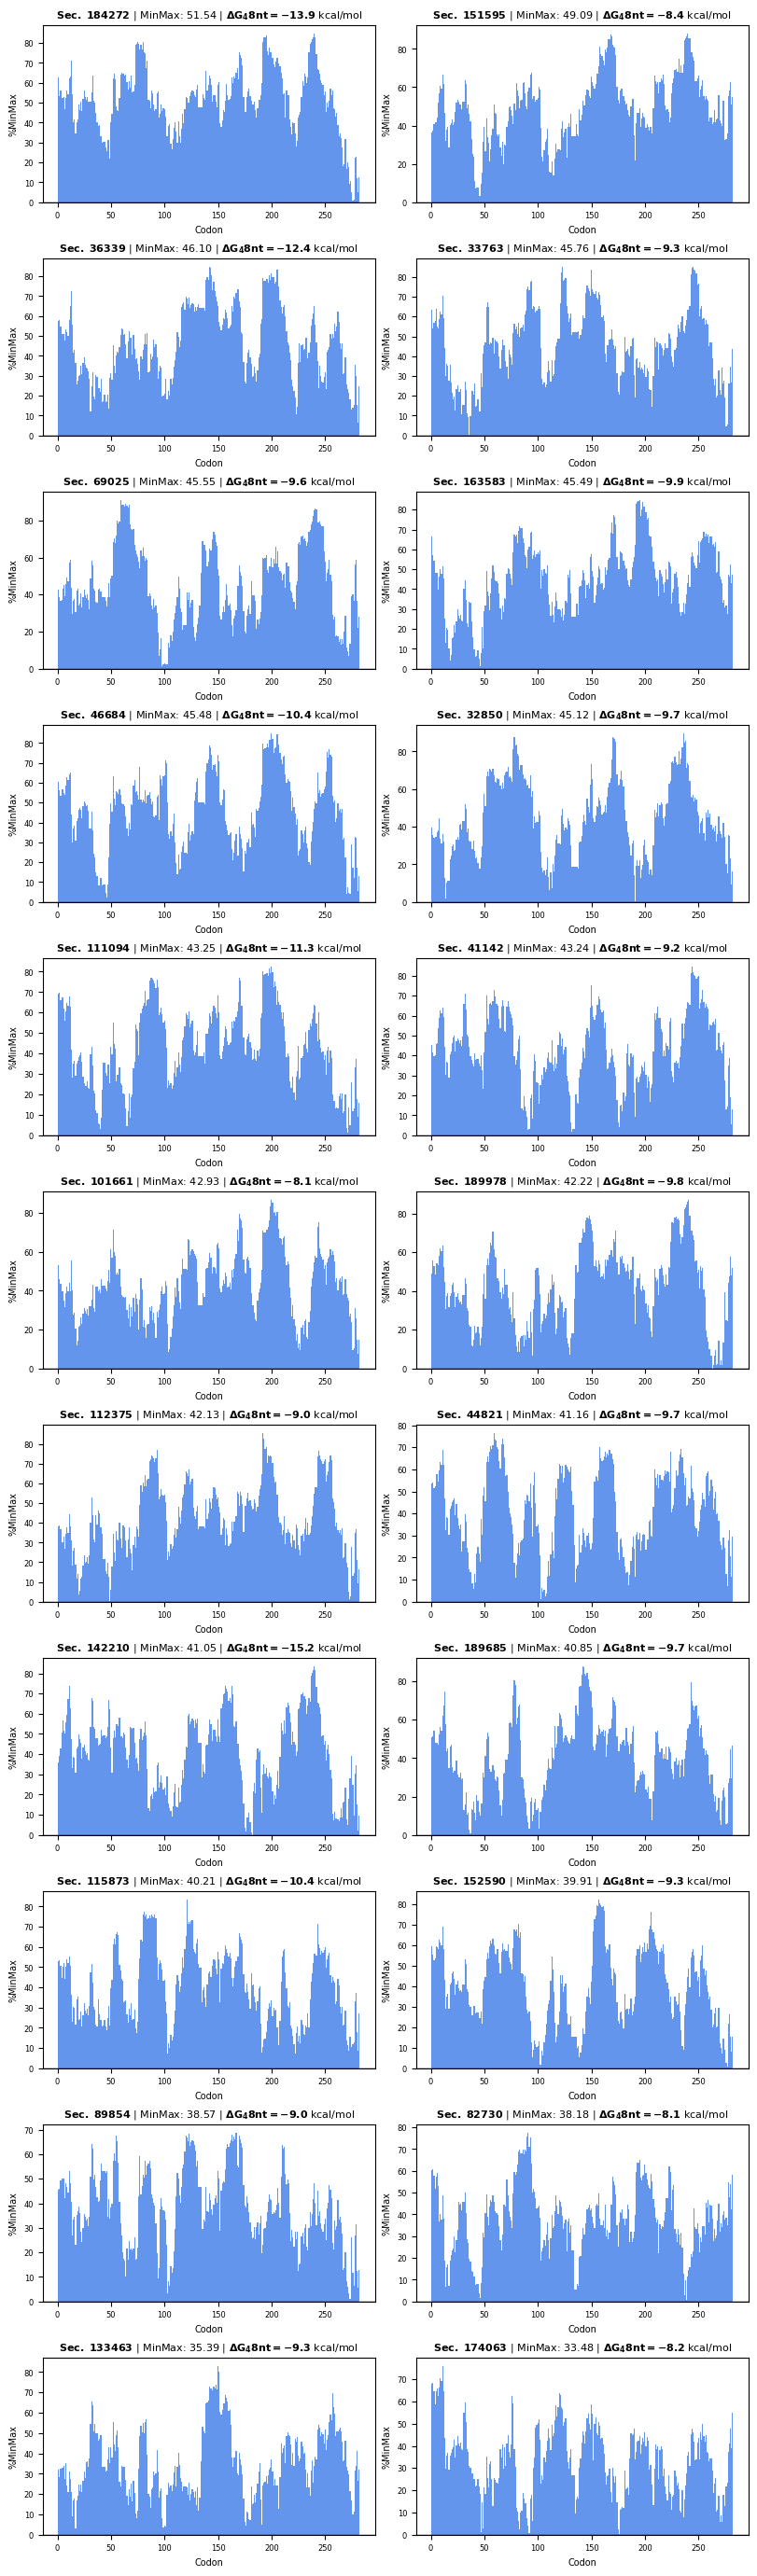

In [ ]:
#@title **Graficar MinMax % (Top50)**

dg_dict = {
    entry["sequence_number"]: entry["ΔG_48nt"]
    for entry in resultados_con_dg
    if "ΔG_48nt" in entry
}

# Usar top50 en lugar de top20_sequences
n_cols = 2
n_rows = int(np.ceil(len(top50) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, n_rows * 2.5),
    constrained_layout=True
)
axes = axes.flatten()

for idx, r in enumerate(top50):
    ax = axes[idx]

    seq = r["dna_sequence"]

    # Obtener su ΔG
    dg = dg_dict.get(r["sequence_number"], None)

    # Obtener valores MinMax
    raw_minmax = CodonEvaluation.get_min_max_percentage(seq, kazusa_table)
    clean_minmax = np.array([x for x in raw_minmax if x is not None], dtype=float)

    if clean_minmax.size == 0:
        ax.set_visible(False)
        continue

    resnum = np.arange(1, len(clean_minmax) + 1)
    bar_colors = ['cornflowerblue' if val >= 0 else 'red' for val in clean_minmax]

    # Gráfico
    ax.bar(resnum, clean_minmax, color=bar_colors, width=1.0)
    ax.axhline(0, color="black", linewidth=1)

    # Título
    if dg is not None:
        titulo_dg = fr"$\bf{{ΔG_48nt = {dg:.1f}}}$ kcal/mol"
    else:
        titulo_dg = r"$\bf{ΔG = N/A}$"

    ax.set_title(
        fr"$\bf{{Sec.\ {r['sequence_number']}}}$ | "
        fr"MinMax: {r['MinMax_score']:.2f} | "
        + titulo_dg,
        fontsize=8
    )

    ax.set_xlabel("Codon", fontsize=7)
    ax.set_ylabel("%MinMax", fontsize=7)
    ax.tick_params(axis='both', labelsize=6)

# Ocultar ejes sobrantes
for j in range(len(top50), len(axes)):
    axes[j].set_visible(False)

graficas_PDF = f"Graficas_{protein_name}_TOP50.pdf"
plt.savefig(graficas_PDF, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
  #@title **Guardar los resultados**
  #@markdown Ejecutar para guardar los resultados en una tabla .csv y las graficas en un archivo pdf.<br>

#@markdown <br>

#@markdown El nombre de los archivos seran Secuencias/Graficas + el nombre de la proteina.<br>

dg_48_dict = {
    entry["sequence_number"]: entry["ΔG_48nt"]
    for entry in resultados_con_dg
    if "ΔG_48nt" in entry
}

secuencias_csv = f"Secuencias_{protein_name}.csv"

data = {
    "sequence_number": [entry["sequence_number"] for entry in top50],
    "dna_sequence": [entry.get("corrected_sequence", entry.get("dna_sequence")) for entry in top50],
    "GC_percent": [
        CodonEvaluation.get_GC_content(entry.get("corrected_sequence", entry.get("dna_sequence")))
        for entry in top50
    ],
    "promedio_minmax": [entry["MinMax_score"] for entry in top50],
    "DeltaG_48nt_kcal/mol": [
        dg_48_dict.get(entry["sequence_number"]) for entry in top50
    ]
}

df_filtered = pd.DataFrame(data)

# Columnas numéricas para formatear
columnas_numericas = ["GC_percent", "promedio_minmax", "DeltaG_48nt_kcal/mol"]

# Reemplazar . por , y limitar a 2 decimales
for col in columnas_numericas:
    df_filtered[col] = df_filtered[col].apply(
        lambda x: f"{x:.2f}".replace('.', ',') if pd.notnull(x) else ""
    )

# Guardar CSV
df_filtered.to_csv(secuencias_csv, index=False)

# Descargar archivo en Colab
files.download(secuencias_csv)

# Descargar gráficos PDF
files.download(graficas_PDF)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>